In [2]:
import pandas as pd
import os
from zipfile import ZipFile
import requests
import io

# Download the official SSA baby names data
# url = "https://www.ssa.gov/oact/babynames/names.zip"
# response = requests.get(url)
# zip_file = ZipFile(io.BytesIO(response.content))

# Prepare a list to collect DataFrames
dfs = []

# Loop through each file in the ZIP
# for file_name in zip_file.namelist():
for file_name in os.listdir('names'):
    if file_name.startswith('yob') and file_name.endswith('.txt'):
        year = int(file_name[3:7])
        if 1880 <= year <= 2023:
            with open(f"names/{file_name}") as file:
                df = pd.read_csv(file, names=["Name", "Gender", "Count"])
                df["Year"] = year
                dfs.append(df)

# Combine all DataFrames into one
all_names_df = pd.concat(dfs, ignore_index=True)
all_names_df.to_csv('names.csv', index=False)
#import ace_tools as tools; tools.display_dataframe_to_user(name="All US Baby Names from 1880 to 2023", dataframe=all_names_df)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_name(name, gender):
    df = pd.read_csv('names.csv')
    name_df = df[(df['Name'] == name) & (df['Gender'] == gender)].sort_values('Year')
    plt.figure(figsize=(12, 7))
    plt.plot(name_df['Year'], name_df['Count'], label=name)
    plt.title(f'Popularity of "{name}" (1880–2023)')
    plt.xlabel('Year')
    plt.ylabel('Number of Newborns')
    plt.grid(True)
    plt.xticks(range(1880, 2030, 10))
    plt.legend()
    plt.show()


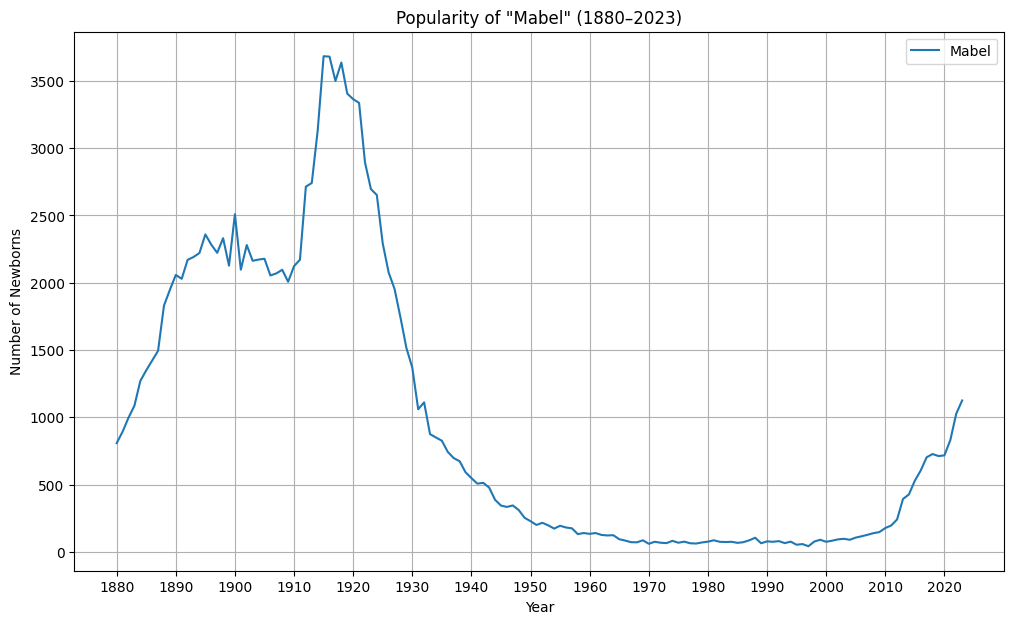

In [15]:
plot_name("Mabel", "F")

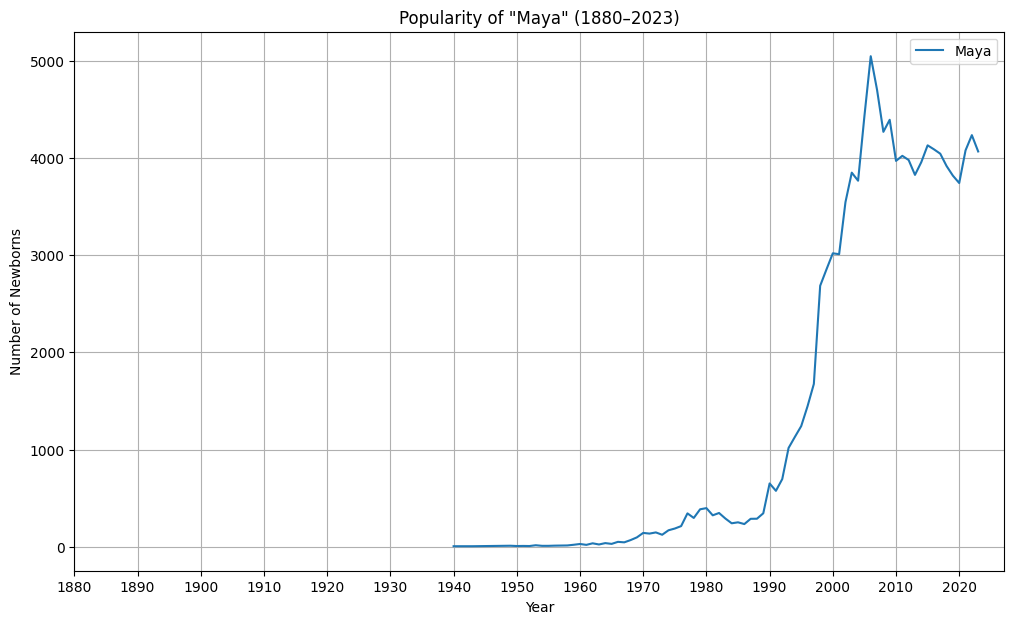

In [16]:
plot_name("Maya", "F")

In [13]:
import pandas as pd

# Load your names CSV
df = pd.read_csv('names.csv')

# Filter for Mabel (female only) and sort by year
mabel_df = df[(df['Name'] == 'Mabel') & (df['Gender'] == 'F')].sort_values('Year')

# Show the full table
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 0)             # Unlimited width
pd.set_option('display.max_colwidth', None)   # Full column content
print(mabel_df)

          Name Gender  Count  Year
21       Mabel      F    808  1880
2022     Mabel      F    893  1881
3956     Mabel      F    997  1882
6083     Mabel      F   1086  1883
8164     Mabel      F   1270  1884
10461    Mabel      F   1349  1885
12755    Mabel      F   1422  1886
15145    Mabel      F   1494  1887
17517    Mabel      F   1830  1888
20167    Mabel      F   1947  1889
22758    Mabel      F   2058  1890
25451    Mabel      F   2029  1891
28115    Mabel      F   2170  1892
31038    Mabel      F   2191  1893
33868    Mabel      F   2221  1894
36809    Mabel      F   2359  1895
39859    Mabel      F   2283  1896
42951    Mabel      F   2222  1897
45980    Mabel      F   2331  1898
49243    Mabel      F   2127  1899
52288    Mabel      F   2509  1900
56016    Mabel      F   2097  1901
59169    Mabel      F   2280  1902
62532    Mabel      F   2163  1903
65923    Mabel      F   2172  1904
69485    Mabel      F   2178  1905
73145    Mabel      F   2054  1906
76780    Mabel      

In [9]:
! pip install ace_tools